<a href="https://colab.research.google.com/github/kshitijksinha07/Credit-Card-Detection-/blob/main/Credit_Card_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from xgboost import XGBClassifier
file_path = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(file_path)
print(df['Class'].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['std_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
counts = y_train.value_counts()
weight = counts[0] / counts[1]
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=weight,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:48:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

auprc = average_precision_score(y_test, y_probs)
print(f"\nArea Under Precision-Recall Curve: {auprc:.4f}")

--- Confusion Matrix ---
[[56838    26]
 [   16    82]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962


Area Under Precision-Recall Curve: 0.8675


In [ ]:
import plotly.figure_factory as ff
from plotly.offline import iplot

In [ ]:
data_df = df
class_0 = data_df.loc[data_df['Class'] == 0]["std_time"]
class_1 = data_df.loc[data_df['Class'] == 1]["std_time"]

hist_data = [class_0, class_1]
group_labels = ['Not Fraud', 'Fraud']

fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)

fig.update_layout(
    title='Credit Card Transactions Time Density Plot (Scaled)',
    xaxis=dict(title='Time (Standardized)'),
    template='plotly_dark'
)

iplot(fig)

In [23]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
file_path = os.path.join(path, 'creditcard.csv')
data_df = pd.read_csv(file_path)

data_df['Hour'] = data_df['Time'].apply(lambda x: np.floor(x / 3600) % 24)

tmp = data_df.groupby(['Hour', 'Class'])['Amount'].aggregate([
    'min', 'max', 'count', 'sum', 'mean', 'median', 'var'
]).reset_index()

stats_df = pd.DataFrame(tmp)
stats_df.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']

df = data_df.copy()
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Summary Statistics (First 5 rows):")
print(stats_df.head())

print("\nModel Features (First 5 rows):")
print(df.head())

Summary Statistics (First 5 rows):
   Hour  Class  Min       Max  Transactions        Sum        Mean   Median  \
0   0.0      0  0.0   7712.43          7689  462388.19   60.136323   12.140   
1   0.0      1  0.0    829.41             6    1820.07  303.345000  230.240   
2   1.0      0  0.0   2481.60          4210  263046.13   62.481266   18.965   
3   1.0      1  1.0    600.73            10    1279.32  127.932000   45.725   
4   2.0      0  0.0  18910.00          3271  229302.70   70.101712   17.450   

             Var  
0   33685.163962  
1  123876.728670  
2   21224.975009  
3   36794.143751  
4  144596.199828  

Model Features (First 5 rows):
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0

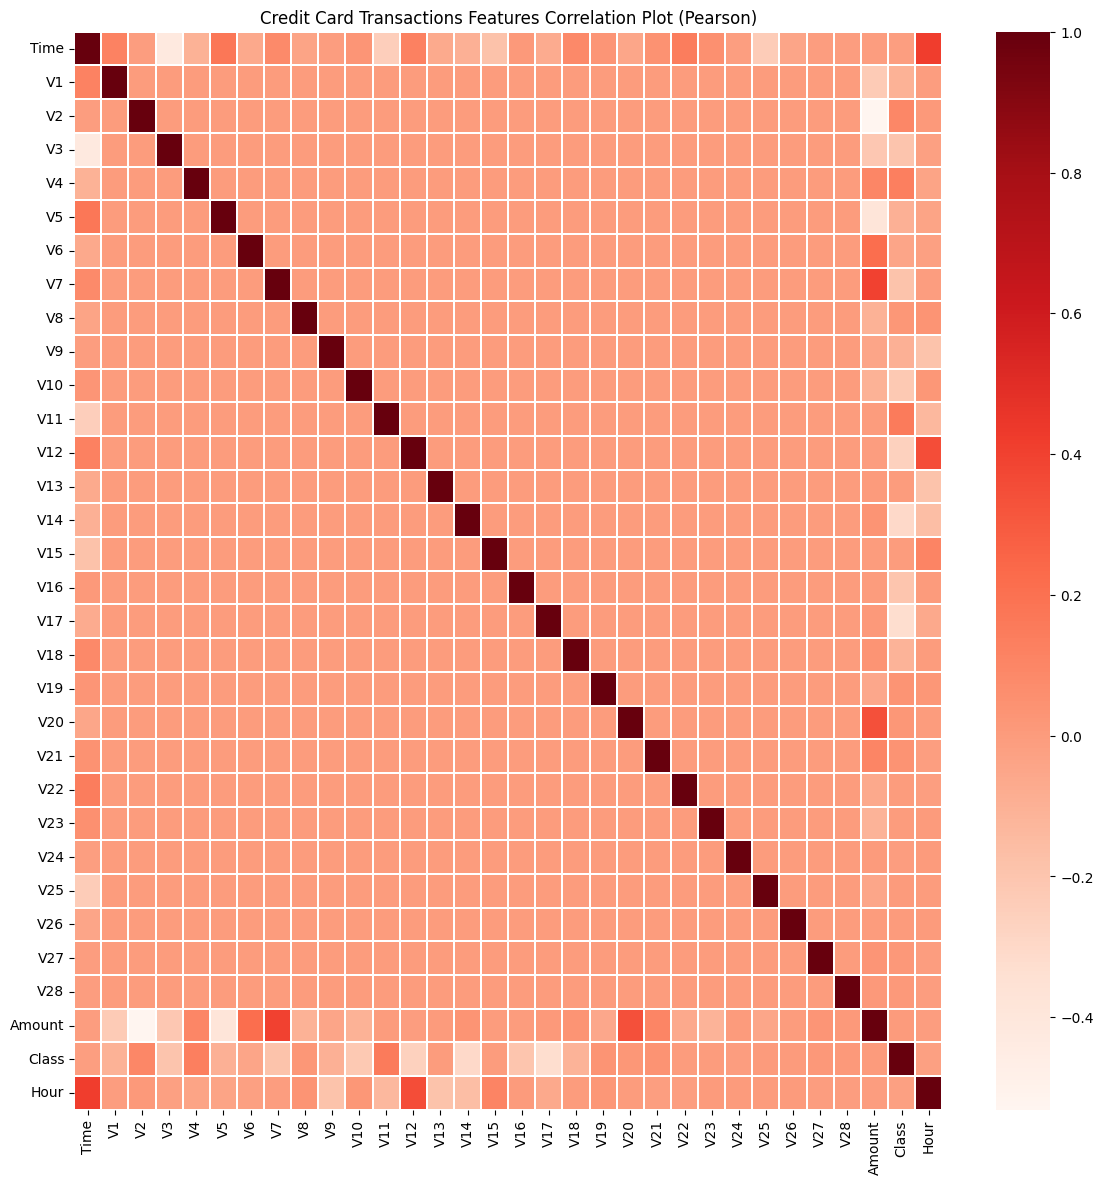

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (14,14))
plt.title('Credit Card Transactions Features Correlation Plot (Pearson)')

corr = data_df.corr()

sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            linewidths=.1,
            cmap="Reds",
            annot=False)

plt.show()

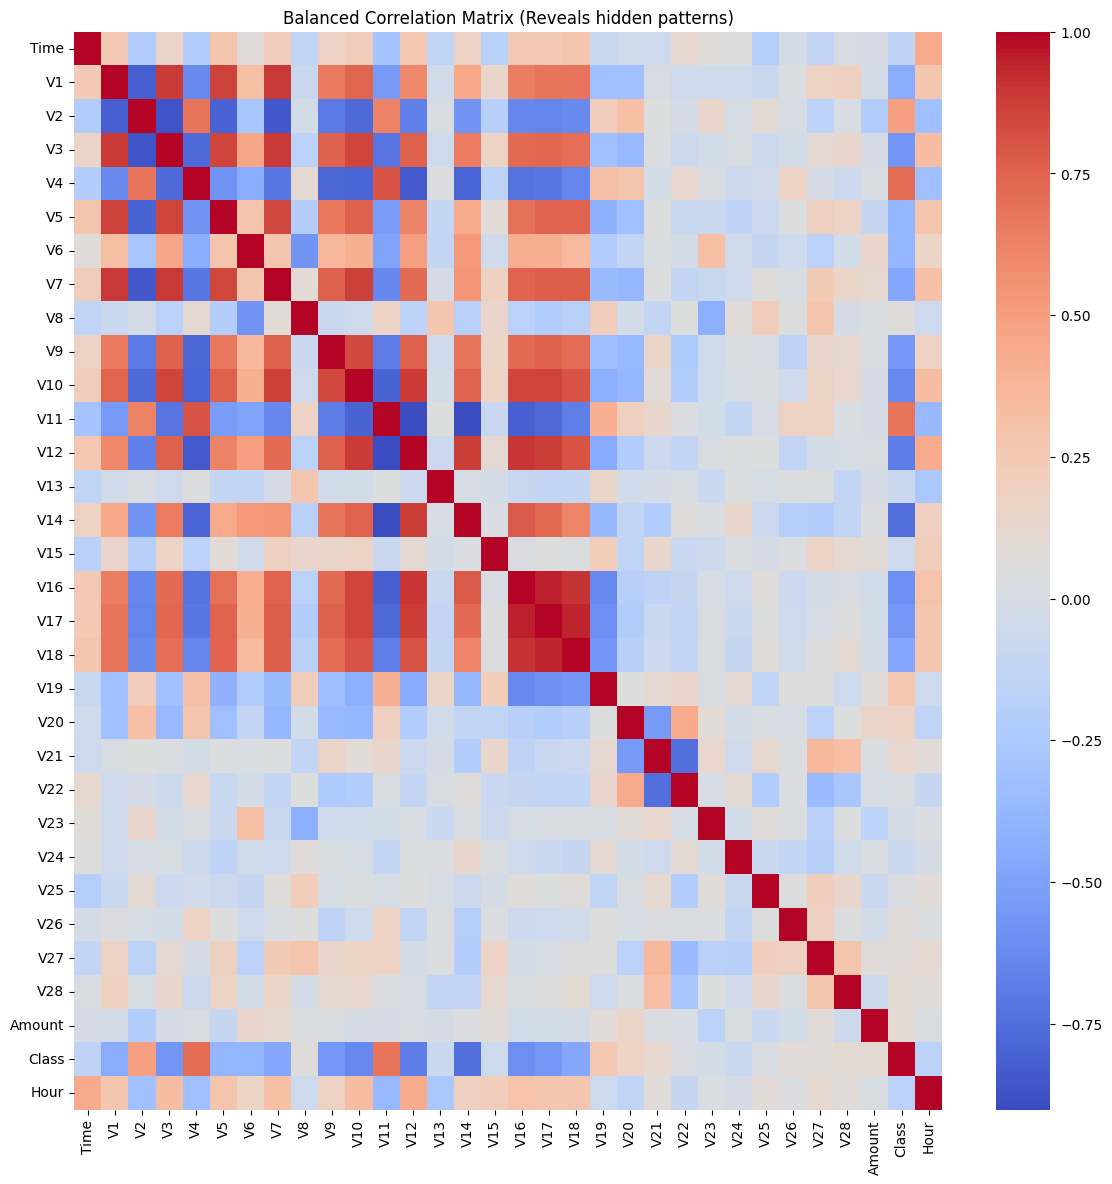

In [ ]:
fraud_df = data_df.loc[data_df['Class'] == 1]
non_fraud_df = data_df.loc[data_df['Class'] == 0].sample(n=492, random_state=42)

normalized_df = pd.concat([fraud_df, non_fraud_df])

plt.figure(figsize=(14,14))
sns.heatmap(normalized_df.corr(), cmap='coolwarm', annot=False)
plt.title('Balanced Correlation Matrix (Reveals hidden patterns)')
plt.show()

In [16]:
import xgboost as xgb

predictors = [col for col in df.columns if col not in ['Class']]
target = 'Class'

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df[target])

dtrain = xgb.DMatrix(train_df[predictors], label=train_df[target])
dvalid = xgb.DMatrix(valid_df[predictors], label=valid_df[target])
dtest = xgb.DMatrix(test_df[predictors], label=test_df[target])

watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

In [17]:
params = {
    'objective': 'binary:logistic',
    'eta': 0.039,
    'max_depth': 2,
    'subsample': 0.8,
    'colsample_bytree': 0.9,
    'eval_metric': 'auc',
    'random_state': 42,
    'verbosity': 0
}

In [18]:
model_native = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=50
)
preds = model_native.predict(dtest)

[0]	train-auc:0.92063	valid-auc:0.92633
[50]	train-auc:0.98196	valid-auc:0.96715
[100]	train-auc:0.98920	valid-auc:0.96111
[102]	train-auc:0.98934	valid-auc:0.96151


In [19]:
MAX_ROUNDS = 1000
EARLY_STOP = 50
VERBOSE_EVAL = 50
RANDOM_STATE = 42
model = xgb.train(
    params,
    dtrain,
    MAX_ROUNDS,
    watchlist,
    early_stopping_rounds=EARLY_STOP,
    maximize=True,
    verbose_eval=VERBOSE_EVAL
)

[0]	train-auc:0.92063	valid-auc:0.92633


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:748: FutureWarning:

Pass `evals` as keyword args.



[50]	train-auc:0.98196	valid-auc:0.96715
[100]	train-auc:0.98920	valid-auc:0.96111
[102]	train-auc:0.98934	valid-auc:0.96151


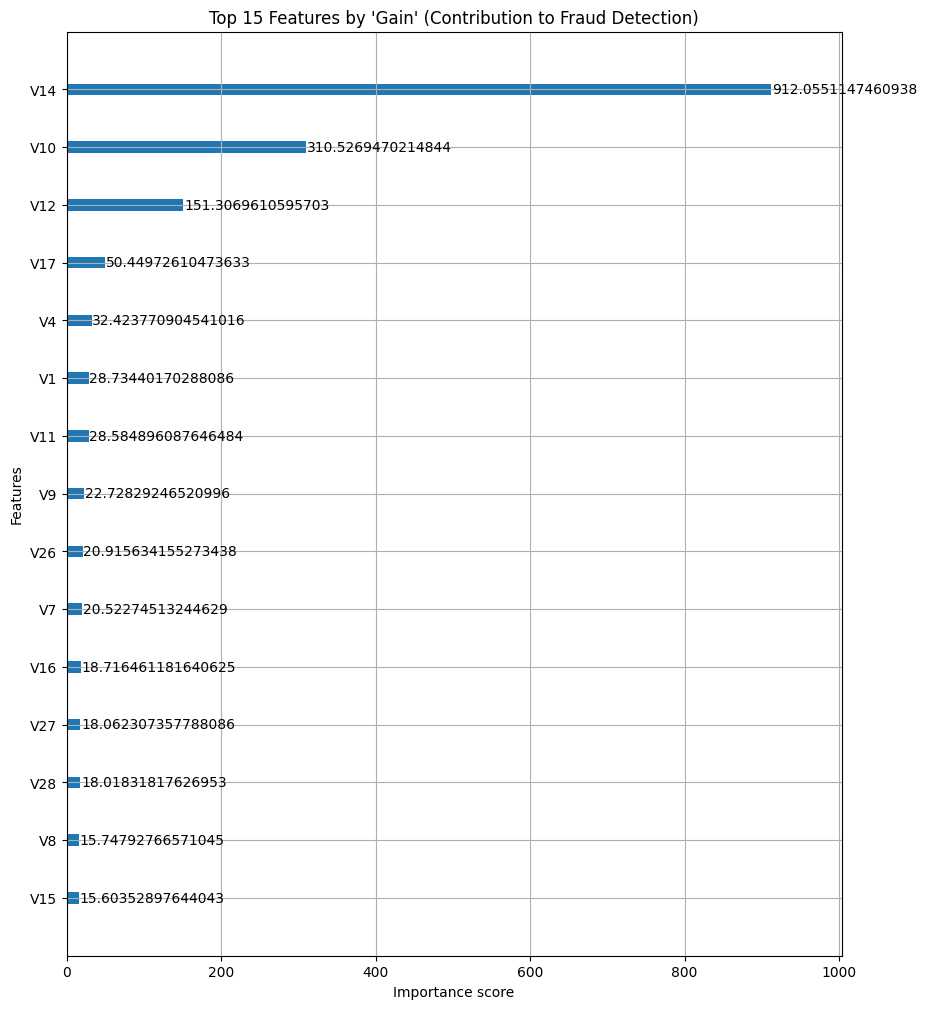

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(model, ax=ax, importance_type='gain', max_num_features=15)
plt.title("Top 15 Features by 'Gain' (Contribution to Fraud Detection)")
plt.show()

In [22]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import gc

n_fold = 0
for train_idx, valid_idx in kf.split(train_df):
    train_x, train_y = train_df[predictors].iloc[train_idx], train_df[target].iloc[train_idx]
    valid_x, valid_y = train_df[predictors].iloc[valid_idx], train_df[target].iloc[valid_idx]

    model = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=80,
        colsample_bytree=0.98,
        subsample=0.78,
        reg_alpha=0.04,
        reg_lambda=0.073,
        objective='binary',
        metric='auc',
        verbose=-1
    )

    callbacks = [
        early_stopping(stopping_rounds=EARLY_STOP),
        log_evaluation(period=VERBOSE_EVAL)
    ]

    model.fit(
        train_x, train_y,
        eval_set=[(valid_x, valid_y)],
        callbacks=callbacks
    )

    oof_preds[valid_idx] = model.predict_proba(valid_x, num_iteration=model.best_iteration_)[:, 1]
    test_preds += model.predict_proba(test_df[predictors], num_iteration=model.best_iteration_)[:, 1] / kf.n_splits

    del train_x, train_y, valid_x, valid_y
    gc.collect()
    n_fold += 1

Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.970451
Early stopping, best iteration is:
[9]	valid_0's auc: 0.977359
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.959266
Early stopping, best iteration is:
[4]	valid_0's auc: 0.962009
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.973188
Early stopping, best iteration is:
[1]	valid_0's auc: 0.979426
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.991955
Early stopping, best iteration is:
[47]	valid_0's auc: 0.992368
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.968203
[100]	valid_0's auc: 0.976265
[150]	valid_0's auc: 0.976624
Early stopping, best iteration is:
[101]	valid_0's auc: 0.979251
